In [1]:
import xarray as xr
import numpy as np
import sys; sys.path.append('../src/training-on-CM2.6')
import matplotlib.pyplot as plt
from helpers.plot_helpers import *
import cmocean
import xgcm
import os
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")

In [2]:
R4_FGR3 = xr.open_dataset('/scratch/pp2681/mom6/Neverworld2/simulations/R32/filter_scale_0.75/merged_dataset.nc', decode_times=False)

In [3]:
static = xr.open_dataset('/scratch/pp2681/mom6/Neverworld2/simulations/R4-long/bare/output/static.nc', decode_times=False).squeeze().drop_vars('time')
grid = xgcm.Grid(static, coords={
            'X': {'center': 'xh', 'outer': 'xq'},
            'Y': {'center': 'yh', 'outer': 'yq'}
        },
        boundary={"X": 'periodic', 'Y': 'fill'},
        fill_value = {'Y':0})

In [4]:
def KEz(ds):
    return 0.5 * (ds.h * (grid.interp(ds.u**2, 'X') + grid.interp(ds.v**2, 'Y'))).sum('zl')

In [5]:
from dask.diagnostics import ProgressBar

In [12]:
R4 = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R4-long/bare/snapshots*', decode_times=False).sel(time=slice(29200.1,None))
R4_ann = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R4-ANN/May22-Coriolis-upd/snapshots*', decode_times=False).sel(time=slice(29200.1,None))

In [17]:
R4_weno = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R4-WENO/WENO7/output/snapshots*.nc', decode_times=False).sel(time=slice(29200.1,None))
R4_ann_weno = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R4-WENO/ANN-WENO7-dissipation/output/snapshots*.nc', decode_times=False).sel(time=slice(29200.1,None))

In [18]:
with ProgressBar():
    R4_KEz = KEz(R4).compute()

[########################################] | 100% Completed | 74.29 s


In [19]:
with ProgressBar():
    R4_ann_KEz = KEz(R4_ann).compute()

[########################################] | 100% Completed | 78.54 s


In [20]:
with ProgressBar():
    R4_weno_KEz = KEz(R4_weno).compute()

[########################################] | 100% Completed | 85.24 ss


In [21]:
with ProgressBar():
    R4_ann_weno_KEz = KEz(R4_ann_weno).compute()

[########################################] | 100% Completed | 74.99 ss


In [22]:
with ProgressBar():
    R4_FGR3_KEz = KEz(R4_FGR3.rename({'hf':'h','uf':'u','vf':'v'})).compute()

In [23]:
import matplotlib as mpl

default_rcParams({'figure.subplot.wspace': 0.0, 'figure.subplot.hspace': 0.3, 'font.size': 14})

def plot(idx=0, zl=slice(None,None)):
    plt.figure(figsize=(11,6))
    for col, (exp, label) in enumerate(
        zip(
        [R4_KEz, 
         R4_ann_KEz,
         R4_weno_KEz,
         R4_ann_weno_KEz,
         R4_FGR3_KEz],
        [
         '$1/4^{\circ}$, Bih. Smag',
         '$1/4^{\circ}$, Big. Smag + ANN',
         '$1/4^{\circ}$, WENO7',
         '$1/4^{\circ}$, ANN+WENO7',
         '$1/32^{\circ}$ filtered \nand coarsegrained']
        )):
        plt.subplot(1,5,col+1)
        KE = exp
        KE = KE.isel(time=idx%len(KE.time))
        im = KE.plot.imshow(
            norm=mpl.colors.LogNorm(vmin=1e-1, vmax=1e+3),
            cmap='inferno',
            add_colorbar=False,
            interpolation='none'
        )
        plt.gca().axes.set_aspect('equal')
        plt.xlabel('')
        plt.ylabel('')
        plt.title(label, fontsize=12)
        lons = [10,30,50]
        plt.xticks(lons, [f'${lon}^'+'{\circ}$E' for lon in lons])
        if col==0:
            lats = [-60, -40, -20, 0, 20, 40, 60]
            lat_ticks = [f'${-lat}^'+'{\circ}$S' if lat<0 else f'${lat}^'+'{\circ}$N' for lat in lats]
            plt.yticks(lats, lat_ticks)
        else:
            plt.yticks([])
            
    plt.colorbar(im, pad=0.08, aspect=100, orientation='horizontal', ax=plt.gcf().axes, extend='both').set_label(fontsize=13, label='Depth-integrated KE, $\mathrm{m}^3 \mathrm{s}^{-2}$')

CPU times: user 96.3 ms, sys: 1.98 ms, total: 98.3 ms
Wall time: 209 ms


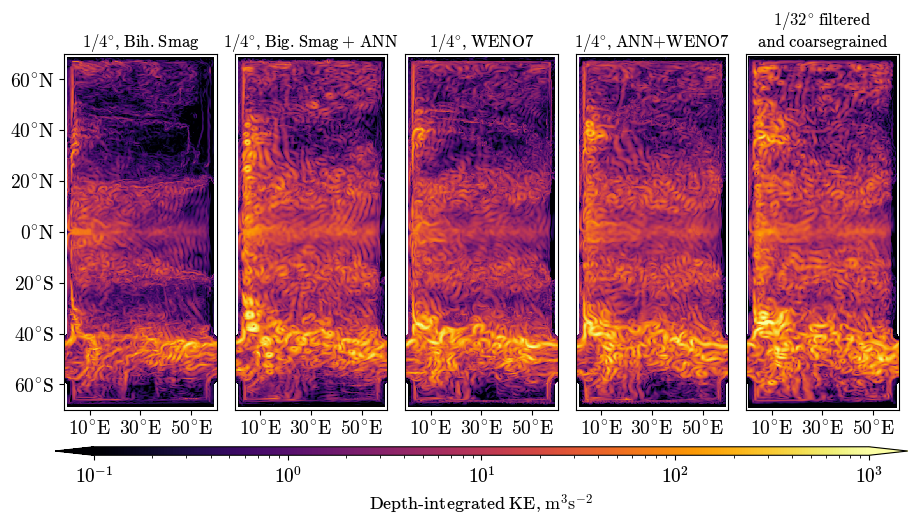

In [24]:
%time plot(0)

In [25]:
from helpers.plot_helpers import create_animation_ffmpeg
%time create_animation_ffmpeg(plot, range(0,160), FPS=20, filename='NW2-WENO.mp4', dpi=150)

Native resolution of snapshots is used: 1374x7789

Animation NW2-WENO.mp4 at FPS=20 will last for 8.0 seconds. The frames are saved to 
.ffmpeg/NW2-WENO

Running the command:
cd /home/pp2681/ANN-momentum-mesoscale/assets; ffmpeg -y -framerate 20 -i .ffmpeg/NW2-WENO/frame-%d.png -s:v 1374x778 -c:v libx264 -profile:v high -crf 20 -pix_fmt yuv420p NW2-WENO.mp4


sh: 1: module: not found
ffmpeg version 4.2.4-1ubuntu0.1 Copyright (c) 2000-2020 the FFmpeg developers
  built with gcc 9 (Ubuntu 9.3.0-10ubuntu2)
  configuration: --prefix=/usr --extra-version=1ubuntu0.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-avresample --disable-filter=resample --enable-avisynth --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librsvg --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --en

CPU times: user 2min 41s, sys: 3.84 s, total: 2min 45s
Wall time: 2min 55s


frame=  160 fps= 30 q=-1.0 Lsize=    9733kB time=00:00:07.85 bitrate=10157.4kbits/s speed=1.46x    
video:9731kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.028401%
[libx264 @ 0x555e44b0fd40] frame I:1     Avg QP:21.56  size:170540
[libx264 @ 0x555e44b0fd40] frame P:40    Avg QP:22.72  size:117667
[libx264 @ 0x555e44b0fd40] frame B:119   Avg QP:25.81  size: 42742
[libx264 @ 0x555e44b0fd40] consecutive B-frames:  0.6%  0.0%  1.9% 97.5%
[libx264 @ 0x555e44b0fd40] mb I  I16..4: 13.5% 51.3% 35.1%
[libx264 @ 0x555e44b0fd40] mb P  I16..4:  0.1% 15.1%  5.4%  P16..4:  4.8% 13.3% 17.5%  0.0%  0.0%    skip:43.9%
[libx264 @ 0x555e44b0fd40] mb B  I16..4:  0.0%  0.5%  0.3%  B16..8: 15.6%  9.9%  6.9%  direct:14.8%  skip:52.0%  L0:13.6% L1:12.4% BI:74.0%
[libx264 @ 0x555e44b0fd40] 8x8 transform intra:69.6% inter:64.4%
[libx264 @ 0x555e44b0fd40] coded y,uvDC,uvAC intra: 94.7% 95.0% 94.9% inter: 38.3% 40.4% 33.1%
[libx264 @ 0x555e44b0fd40] i16 v,h,dc,p: 61% 29% 11%  0